In [3]:
from math import comb

def prob_al_menos_2(n, p):
    """
    Calcula la probabilidad de que al menos 2 inversores
    estén a favor, dado n inversores y probabilidad p.
    
    n: número de inversores
    p: probabilidad de que un inversor esté a favor
    """
    # Probabilidad de 0 a favor
    p0 = comb(n, 0) * (p**0) * ((1-p)**n)
    # Probabilidad de 1 a favor
    p1 = comb(n, 1) * (p**1) * ((1-p)**(n-1))
    
    return 1 - (p0 + p1)

# Ejemplo: 5 inversores, probabilidad 0.6 de estar a favor
n = 3
p = 0.6
resultado = prob_al_menos_2(n, p)
print(f"Probabilidad de al menos 2 a favor: {resultado:.4f}")


print(comb(3,2)*(0.4*0.4)*0.6**1)

print(comb(3,2))

Probabilidad de al menos 2 a favor: 0.6480
0.28800000000000003
3


In [4]:
print((0.432*0.3)+(0.288*0.7))

0.33119999999999994


In [5]:
0.1296/0.3312

0.3913043478260869

Procesos estocasticos (O-U)


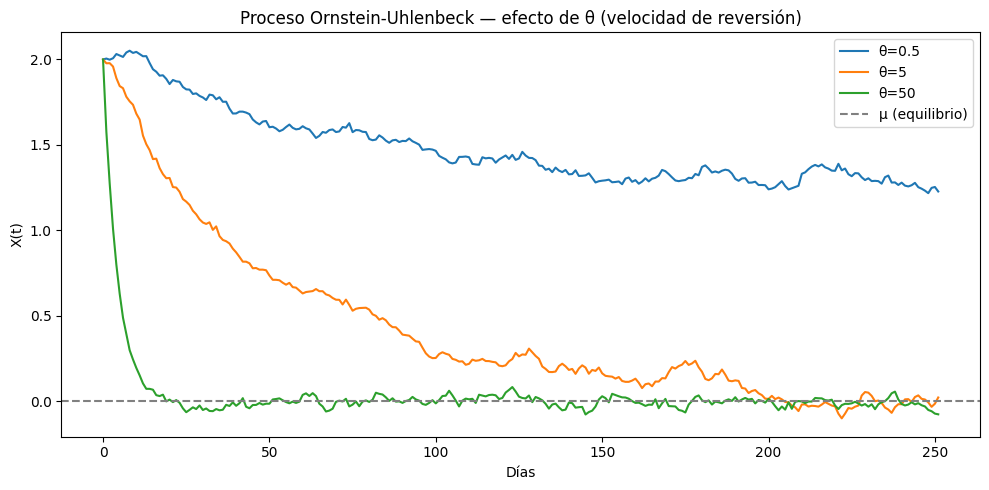

In [16]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
T = 252
dt = 1/252
mu = 0       # nivel de equilibrio
sigma = 0.3  # volatilidad del ruido

fig, ax = plt.subplots(figsize=(10, 5))

for theta in [0.5, 5, 50]:
    X = np.zeros(T)
    X[0] = 2  # empieza lejos del equilibrio
    
    for t in range(1, T):
        dW = np.random.normal(0, np.sqrt(dt))
        X[t] = X[t-1] + theta*(mu - X[t-1])*dt + sigma*dW
    
    ax.plot(X, label=f"θ={theta}")

ax.axhline(mu, color='gray', linestyle='--', label="μ (equilibrio)")
ax.set_title("Proceso Ornstein-Uhlenbeck — efecto de θ (velocidad de reversión)")
ax.set_xlabel("Días")
ax.set_ylabel("X(t)")
ax.legend()
plt.tight_layout()
plt.show()

Estimacion de theta de un spread real con regresion simple

[*********************100%***********************]  2 of 2 completed


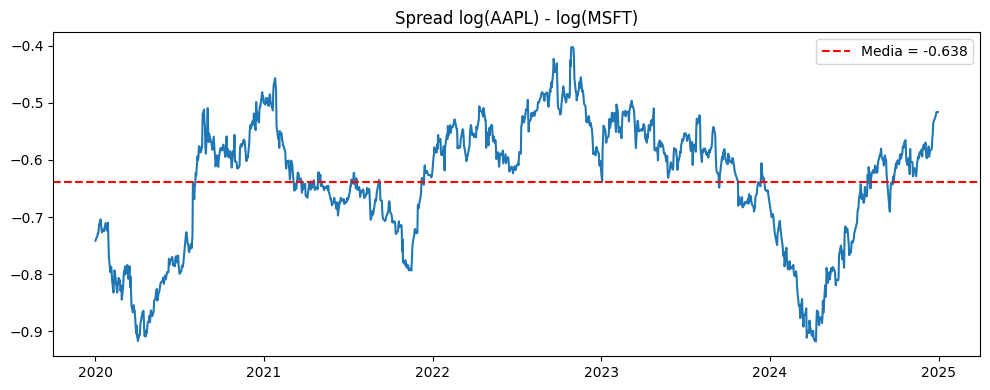

Coeficiente b: -0.00800
Theta estimado (velocidad de reversión): 2.017
Mu (nivel de equilibrio del spread): -0.6157

Vida media de reversión (días): 0.3

p-value de b: 0.02626
¿Reversión estadísticamente significativa? Sí


In [3]:
import numpy as np
import pandas as pd
import yfinance as yf
import statsmodels.api as sm
import matplotlib.pyplot as plt

data = yf.download(["AAPL", "MSFT"], start="2020-01-01", end="2024-12-31")["Close"]

spread = np.log(data["AAPL"]) - np.log(data["MSFT"])
spread = spread.dropna()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(spread)
ax.axhline(spread.mean(), color='red', linestyle='--', label=f"Media = {spread.mean():.3f}")
ax.set_title("Spread log(AAPL) - log(MSFT)")
ax.legend()
plt.tight_layout()
plt.show()

# --- Estimar theta vía regresión discreta de Ornstein-Uhlenbeck ---
X_t = spread.shift(1).dropna()
delta_X = spread.diff().dropna()

X_t, delta_X = X_t.align(delta_X, join='inner')

# Renombrar explícitamente para evitar el KeyError de .name perdido
X_t = X_t.rename("X_t")
delta_X = delta_X.rename("delta_X")

X_reg = sm.add_constant(X_t)
modelo_ou = sm.OLS(delta_X, X_reg).fit()

a = modelo_ou.params["const"]
b = modelo_ou.params["X_t"]   # ahora el nombre es fijo, no depende de .name

dt = 1/252
theta = -b / dt
mu_equilibrio = -a / b

print(f"Coeficiente b: {b:.5f}")
print(f"Theta estimado (velocidad de reversión): {theta:.3f}")
print(f"Mu (nivel de equilibrio del spread): {mu_equilibrio:.4f}")
print(f"\nVida media de reversión (días): {np.log(2)/theta:.1f}")
print(f"\np-value de b: {modelo_ou.pvalues['X_t']:.5f}")
print(f"¿Reversión estadísticamente significativa? "
      f"{'Sí' if modelo_ou.pvalues['X_t'] < 0.05 else 'No'}")

In [4]:
print(f"theta calculado: {theta}")
print(f"ln(2)/theta = {np.log(2)/theta}")

theta calculado: 2.016824833112444
ln(2)/theta = 0.34368239084514496
